(7,)
i    5
j    6
dtype: int64


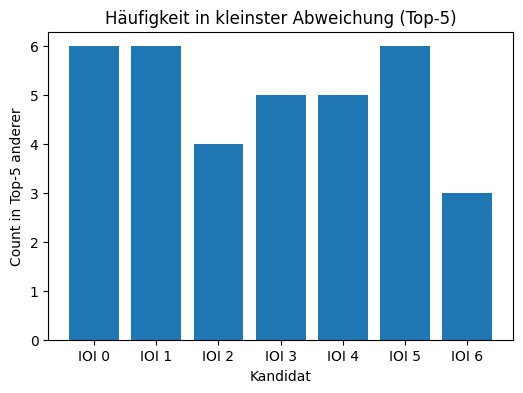

    index    ioi  K_int  base_candidate  pair_with     ratio  proximity  \
0       0  2.006      1           2.006          1  1.006523   0.995987   
1       0  2.006      1           2.006          3  1.034554   0.905314   
2       0  2.006      1           2.006          5  1.066800   0.688619   
3       0  2.006      1           2.006          2  1.075027   0.623512   
4       0  2.006      1           2.006          4  1.124128   0.262996   
5       1  1.993      1           1.993          0  1.006523   0.995987   
6       1  1.993      1           1.993          3  1.027849   0.937151   
7       1  1.993      1           1.993          2  1.068060   0.678763   
8       1  1.993      1           1.993          5  1.073758   0.633647   
9       1  1.993      1           1.993          4  1.131460   0.221568   
10      2  1.866      1           1.866          3  1.039121   0.880443   
11      2  1.866      1           1.866          1  1.068060   0.678763   
12      2  1.866      1  

In [4]:
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Basis-IOI aus Paaren bestimmen (LCM-Methode)
# =============================
def best_fit_ioi_from_pairs(iois, df_pairs, threshold):
    valid_pairs = df_pairs[df_pairs["proximity"] > threshold]
    fractions_list = []
    for label in valid_pairs["peak_label"]:
        if label != "Keine Proximity":
            num, den = map(int, label.split("/"))
            fractions_list.append(Fraction(num, den))

    if not fractions_list:
        return None

    denominators = [frac.denominator for frac in fractions_list]
    lcm_den = np.lcm.reduce(denominators)

    # Vielfachfaktor pro IOI bestimmen
    k_values = [None] * len(iois)
    for idx in range(len(iois)):
        factors = []
        for _, row in valid_pairs.iterrows():
            if row["peak_label"] == "Keine Proximity":
                continue
            num, den = map(int, row["peak_label"].split("/"))
            frac = Fraction(num, den)
            num_scaled = frac.numerator * (lcm_den // frac.denominator)
            if row["i"] == idx:
                factors.append(num_scaled)
            elif row["j"] == idx:
                factors.append(num_scaled)
        if factors:
            k_values[idx] = min(factors)

    if any(k is None for k in k_values):
        print("Warnung: Nicht für alle IOIs ein Faktor gefunden.")
        return None

    base_ioi = np.mean([iois[i] / k_values[i] for i in range(len(iois))])
    return base_ioi

# =============================
# 4) Parameter, Daten laden & Pairs bauen
# =============================
params = dict(
    sharpness_base=8.0,
    sharpness_growth=0.5,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

filename = "KWA6.csv"
base_dir = Path("../data/Kwa-Sounds Scorpaena spp./")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

# Nur gültige IOIs verwenden
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairs sofort neu berechnen – kein alter Cache!
df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# =============================
# compute_ioi_positions_fixed – jetzt mit Auto-Check
# =============================
def compute_ioi_positions_fixed(iois, df_pairs, threshold=0.01, verbose=False):
    """
    Aus Paar-DF -> IOI-Positions-DF mit konsistenter Netzwerk-Skalierung.
    Immer 5 Zeilen pro IOI (mit evtl. 0-Abweichung).
    Außerdem am Ende: Barplot mit Counts pro Kandidat.
    """

    # --- Sicherheitscheck ---
    max_index_in_pairs = max(df_pairs["i"].max(), df_pairs["j"].max())
    if max_index_in_pairs >= len(iois):
        print("⚠️ df_pairs passt nicht zu iois – baue neu...")
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params, threshold=threshold)

    n = len(iois)

    # --- 1) Kantenliste ---
    edges = []
    for r in df_pairs.itertuples():
        if getattr(r, "proximity", 0) <= threshold:
            continue
        label = getattr(r, "peak_label", "")
        if not label or label == "Keine Proximity":
            continue
        try:
            p, q = map(int, label.split("/"))
        except Exception:
            continue
        if r.ioi_i >= r.ioi_j:
            u, v, frac = int(r.i), int(r.j), Fraction(p, q)
        else:
            u, v, frac = int(r.j), int(r.i), Fraction(p, q)
        edges.append((u, v, frac))

    # --- 2) BFS / Propagation ---
    K_rel = [None] * n
    seed = int(np.argmax(iois))
    K_rel[seed] = Fraction(1, 1)
    changed = True
    for _ in range(10 * n):
        if not changed:
            break
        changed = False
        for u, v, frac in edges:
            if K_rel[u] is not None and K_rel[v] is None:
                K_rel[v] = K_rel[u] * Fraction(frac.denominator, frac.numerator)
                changed = True
            elif K_rel[v] is not None and K_rel[u] is None:
                K_rel[u] = K_rel[v] * frac
                changed = True
    for idx, val in enumerate(K_rel):
        if val is None:
            K_rel[idx] = Fraction(1, 1)

    # --- 3) Basistakt ---
    K_rel_float = np.array([float(k) for k in K_rel])
    base_candidates = np.array(iois) / K_rel_float
    t0 = float(np.median(base_candidates))
    if t0 <= 0:
        raise RuntimeError("Ungültiger t0")

    # --- 4) Ganzzahlige K_int ---
    K_int = np.rint(np.array(iois) / t0).astype(int)
    K_int[K_int < 1] = 1
    g = int(reduce(gcd, K_int.tolist()))
    if g > 1:
        K_int //= g

    # --- 5) DataFrame (Top-5 Paare) ---
    rows = []
    for i in range(n):
        pairs_i = df_pairs[(df_pairs["i"] == i) | (df_pairs["j"] == i)]
        pairs_i = pairs_i.sort_values(by="proximity", ascending=False)
        while len(pairs_i) < 5:
            pairs_i = pd.concat([pairs_i, pd.DataFrame([{
                "i": i, "j": None, "ioi_i": iois[i], "ioi_j": None,
                "ratio": None, "proximity": 0.0, "peak_label": "Keine Abweichung"
            }])], ignore_index=True)
        top5 = pairs_i.head(5)
        for _, r in top5.iterrows():
            rows.append({
                "index": i,
                "ioi": iois[i],
                "K_int": int(K_int[i]),
                "base_candidate": float(iois[i] / K_int[i]),
                "pair_with": r["j"] if r["i"] == i else r["i"],
                "ratio": r["ratio"],
                "proximity": r["proximity"],
                "peak_label": r["peak_label"]
            })

    df_ioi_positions = pd.DataFrame(rows)

    # --- 6) Barplot ---
    counts = df_ioi_positions["pair_with"].value_counts().sort_index()
    plt.figure(figsize=(6, 4))
    plt.bar(range(len(counts)), counts.values, tick_label=[f"IOI {i}" for i in counts.index])
    plt.xlabel("Kandidat")
    plt.ylabel("Count in Top-5 anderer")
    plt.title("Häufigkeit in kleinster Abweichung (Top-5)")
    plt.show()

    if verbose:
        print("t0:", t0)
        print("K_int:", K_int.tolist())

    return df_ioi_positions, t0

# =============================
# Anwendung auf Daten
# =============================
print(iois.shape)
print(df_pairs[['i', 'j']].max())

df_ioi_positions, t0 = compute_ioi_positions_fixed(iois, df_pairs, threshold=PAIR_THRESHOLD)

if df_ioi_positions is not None:
    print(df_ioi_positions)
    print("\nGemittelter Basis-IOI:", df_ioi_positions["base_candidate"].mean())
else:
    print("Keine gültigen Verhältnisse gefunden.")


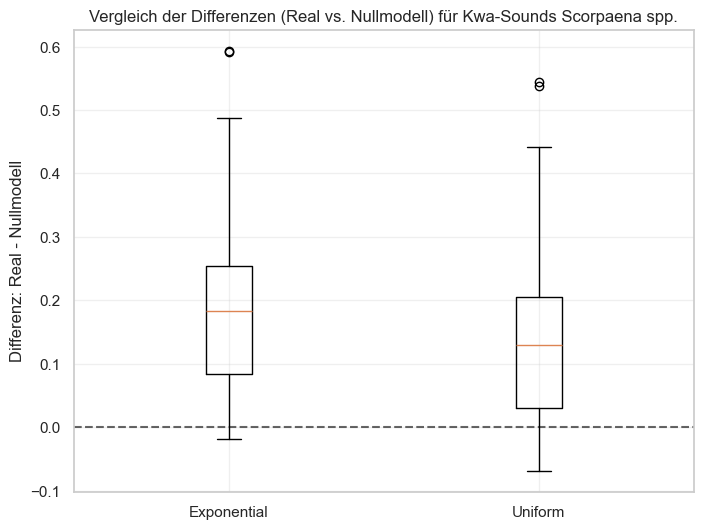

     filename  real_mean  expon_mean  uniform_mean  diff_real_expon_mean  \
0  KWA9-C.csv   0.397474    0.232470      0.285818              0.165004   
1    KWA2.csv   0.553497    0.236835      0.283270              0.316661   
2    KWA3.csv   0.824276    0.231052      0.280575              0.593224   
3   KWA10.csv   0.422926    0.237031      0.289761              0.185895   
4    KWA1.csv   0.252510    0.234905      0.283289              0.017605   

   diff_real_uniform_mean  
0                0.111656  
1                0.270227  
2                0.543701  
3                0.133165  
4               -0.030779  


In [91]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion für IOI-Analyse und Folderanalyse
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs
def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    # Alle CSV-Dateien im Ordner durchgehen
    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        fpath = os.path.join(folder_path, fname)
        last_dir = os.path.basename(folder_path)
        df = pd.read_csv(fpath)

        if "IOI" not in df.columns:
            print(f"⚠️ Datei {fname} übersprungen (keine IOI-Spalte).")
            continue

        iois = df["IOI"].dropna().values
        onsets = df["onset"].dropna().values if "onset" in df.columns else None

        if len(iois) < 3:
            print(f"⚠️ Datei {fname} übersprungen (zu wenig IOIs).")
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Reale Proximity-Paare ---
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Nullmodell: Exponential ---
        proximity_expon_all = []
        for seq_idx in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        # --- Nullmodell: Uniform ---
        proximity_uniform_all = []
        for seq_idx in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_uniform_all.append(prox_mat[triu_idx])
        proximity_uniform_all = np.concatenate(proximity_uniform_all)
        mean_uniform = np.mean(proximity_uniform_all)

        # --- Ergebnisse speichern ---
        results_list.append({
            "filename": fname,
            "real_mean": mean_real,
            "expon_mean": mean_expon,
            "uniform_mean": mean_uniform,
            "diff_real_expon_mean": mean_real - mean_expon,
            "diff_real_uniform_mean": mean_real - mean_uniform,
        })

    # Alles in DataFrame
    results_df = pd.DataFrame(results_list)

    # --- Boxplot ---
    plt.figure(figsize=(8, 6))
    plt.boxplot(
    [results_df["diff_real_expon_mean"], results_df["diff_real_uniform_mean"]],
    tick_labels=["Exponential", "Uniform"]
    )
    plt.axhline(0, color="black", linestyle="--", alpha=0.6)
    plt.ylabel("Differenz: Real - Nullmodell")
    plt.title(f"Vergleich der Differenzen (Real vs. Nullmodell) für {last_dir}")
    plt.grid(alpha=0.3)
    plt.show()

    return results_df
params = dict(
    sharpness_base=2.052513,
    sharpness_growth=0.523924,
    decay=0.186837,
    max_freq=1,
    weight_exponent=1.182288,
    freq_sharpness_exp=1.361429,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

# === Anwendung ===
folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."
results_df = analyze_folder(folder_path, params, num_sequences=1000, seed=6)
print(results_df.head())


=== Ergebnisse pro decay-Wert ===
       decay  median_diff
0   0.000000     0.092580
1   0.050725     0.091255
2   0.101449     0.094131
3   0.152174     0.098198
4   0.202899     0.101868
..       ...          ...
65  3.297101     0.109745
66  3.347826     0.109707
67  3.398551     0.109663
68  3.449275     0.109614
69  3.500000     0.109561

[70 rows x 2 columns]

➡️ Bester decay-Wert: 0.35507246376811596 (Median diff_real_expon_mean = 0.1107)


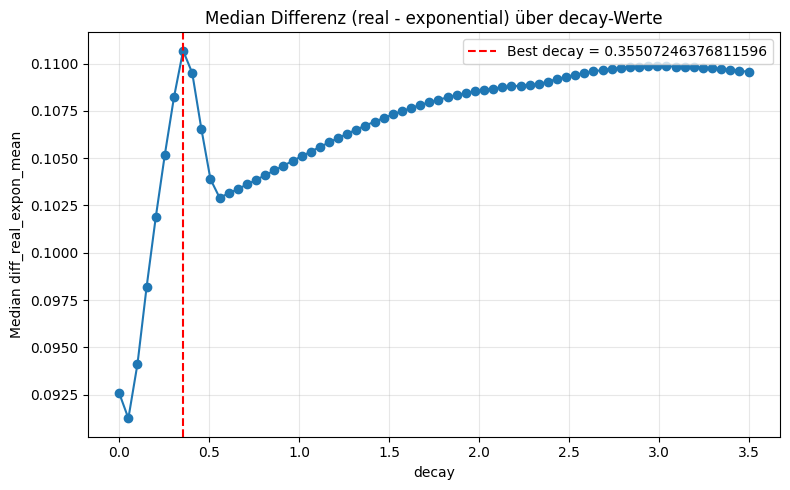

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion für IOI-Analyse und Folderanalyse
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs


def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    # Alle CSV-Dateien im Ordner durchgehen
    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        fpath = os.path.join(folder_path, fname)
        df = pd.read_csv(fpath)

        if "IOI" not in df.columns:
            print(f"⚠️ Datei {fname} übersprungen (keine IOI-Spalte).")
            continue

        iois = df["IOI"].dropna().values
        onsets = df["onset"].dropna().values if "onset" in df.columns else None

        if len(iois) < 3:
            print(f"⚠️ Datei {fname} übersprungen (zu wenig IOIs).")
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Reale Proximity-Paare ---
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Nullmodell: Exponential ---
        proximity_expon_all = []
        for seq_idx in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        # --- Nullmodell: Uniform ---
        proximity_uniform_all = []
        for seq_idx in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_uniform_all.append(prox_mat[triu_idx])
        proximity_uniform_all = np.concatenate(proximity_uniform_all)
        mean_uniform = np.mean(proximity_uniform_all)

        # --- Ergebnisse speichern ---
        results_list.append({
            "filename": fname,
            "real_mean": mean_real,
            "expon_mean": mean_expon,
            "uniform_mean": mean_uniform,
            "diff_real_expon_mean": mean_real - mean_expon,
            "diff_real_uniform_mean": mean_real - mean_uniform,
        })

    return pd.DataFrame(results_list)


# === Parameter-Scan über decay ===
decay_values = np.linspace(0, 3.5, 70)


best_decay = None
best_median = -np.inf
all_results = []

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."

for d in decay_values:
    params_test = dict(
        sharpness_base=8.0,
        sharpness_growth=0.5,
        decay=d,
        max_freq=4,
        weight_exponent=1.0,
        freq_sharpness_exp=1.0,
        norm_x=1.0,
        output_max=1.0
    )
    results_df = analyze_folder(folder_path, params_test, num_sequences=100, seed=42)
    median_val = results_df["diff_real_expon_mean"].median()
    all_results.append({"decay": d, "median_diff": median_val})

    if median_val > best_median:
        best_median = median_val
        best_decay = d

# Alles in DataFrame packen
summary_df = pd.DataFrame(all_results)

print("=== Ergebnisse pro decay-Wert ===")
print(summary_df)

print(f"\n➡️ Bester decay-Wert: {best_decay} (Median diff_real_expon_mean = {best_median:.4f})")

# === Plot hinzufügen ===
plt.figure(figsize=(8,5))
plt.plot(summary_df["decay"], summary_df["median_diff"], marker="o", linestyle="-")
plt.axvline(best_decay, color="red", linestyle="--", label=f"Best decay = {best_decay}")
plt.title("Median Differenz (real - exponential) über decay-Werte")
plt.xlabel("decay")
plt.ylabel("Median diff_real_expon_mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

decay=0.00, sharpness_base=5.00 -> median=0.1220
decay=0.00, sharpness_base=8.75 -> median=0.0858
decay=0.00, sharpness_base=12.50 -> median=0.0764
decay=0.00, sharpness_base=16.25 -> median=0.0717
decay=0.00, sharpness_base=20.00 -> median=0.0672
decay=0.05, sharpness_base=5.00 -> median=0.1192
decay=0.05, sharpness_base=8.75 -> median=0.0858
decay=0.05, sharpness_base=12.50 -> median=0.0761
decay=0.05, sharpness_base=16.25 -> median=0.0734
decay=0.05, sharpness_base=20.00 -> median=0.0673
decay=0.11, sharpness_base=5.00 -> median=0.1152
decay=0.11, sharpness_base=8.75 -> median=0.0850
decay=0.11, sharpness_base=12.50 -> median=0.0788
decay=0.11, sharpness_base=16.25 -> median=0.0731
decay=0.11, sharpness_base=20.00 -> median=0.0674
decay=0.16, sharpness_base=5.00 -> median=0.1118
decay=0.16, sharpness_base=8.75 -> median=0.0887
decay=0.16, sharpness_base=12.50 -> median=0.0802
decay=0.16, sharpness_base=16.25 -> median=0.0728
decay=0.16, sharpness_base=20.00 -> median=0.0673
decay=0.

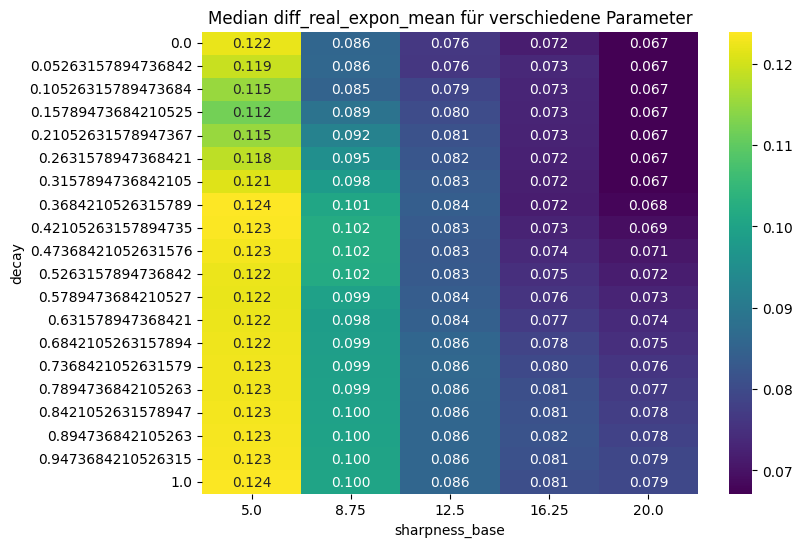


➡️ Beste Kombination: decay=0.3684210526315789, sharpness_base=5.0 (Median diff_real_expon_mean = 0.1239)


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# ================================
# proximity_max_freq bleibt unverändert
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# ================================
# analyze_folder bleibt unverändert
# ================================
def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []
    last_dir = os.path.basename(folder_path)

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        fpath = os.path.join(folder_path, fname)
        df = pd.read_csv(fpath)

        if "IOI" not in df.columns:
            print(f"⚠️ Datei {fname} übersprungen (keine IOI-Spalte).")
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            print(f"⚠️ Datei {fname} übersprungen (zu wenig IOIs).")
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Reale Proximity-Paare ---
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Nullmodell: Exponential ---
        proximity_expon_all = []
        for seq_idx in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        results_list.append({
            "filename": fname,
            "diff_real_expon_mean": mean_real - mean_expon
        })

    results_df = pd.DataFrame(results_list)
    return results_df

# ================================
# Parameter-Grid definieren
# ================================
decay_values = np.linspace(0, 1.0, 20)
sharpness_values = np.linspace(5, 20, 5)

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."

grid_results = []

for decay, sharpness in itertools.product(decay_values, sharpness_values):
    params_test = dict(
        sharpness_base=sharpness,
        sharpness_growth=0.5,
        decay=decay,
        max_freq=4,
        weight_exponent=1.0,
        freq_sharpness_exp=1.0,
        norm_x=1.0,
        output_max=1.0
    )
    res_df = analyze_folder(folder_path, params_test, num_sequences=100)
    median_val = res_df["diff_real_expon_mean"].median()
    grid_results.append({
        "decay": decay,
        "sharpness_base": sharpness,
        "median_diff": median_val
    })
    print(f"decay={decay:.2f}, sharpness_base={sharpness:.2f} -> median={median_val:.4f}")

# ================================
# Ergebnisse als DataFrame
# ================================
grid_df = pd.DataFrame(grid_results)

# Heatmap vorbereiten
heatmap_data = grid_df.pivot(index="decay", columns="sharpness_base", values="median_diff")

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("sharpness_base")
plt.ylabel("decay")
plt.title("Median diff_real_expon_mean für verschiedene Parameter")
plt.show()

# Besten Parameterwert ausgeben
best_idx = grid_df["median_diff"].idxmax()
best_params = grid_df.loc[best_idx]
print(f"\n➡️ Beste Kombination: decay={best_params.decay}, sharpness_base={best_params.sharpness_base} "
      f"(Median diff_real_expon_mean = {best_params.median_diff:.4f})")


In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

# proximity_max_freq bleibt unverändert
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# analyze_folder bleibt unverändert
def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        fpath = os.path.join(folder_path, fname)
        df = pd.read_csv(fpath)

        if "IOI" not in df.columns or len(df["IOI"].dropna()) < 3:
            continue

        iois = df["IOI"].dropna().values
        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # Reale Proximity-Paare
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # Nullmodell: Exponential
        proximity_expon_all = []
        for _ in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        results_list.append({
            "filename": fname,
            "diff_real_expon_mean": mean_real - mean_expon
        })

    return pd.DataFrame(results_list)

# ================================
# Parameter-Grid für 6 Parameter
# ================================
param_grid = {
    "sharpness_base": np.linspace(5, 15, 3),
    "sharpness_growth": np.linspace(0.2, 1.0, 3),
    "decay": np.linspace(0.1, 1.0, 3),
    "max_freq": [2, 4, 6],
    "weight_exponent": [0.5, 1.0, 1.5],
    "freq_sharpness_exp": [0.5, 1.0, 1.5]
}

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."
all_param_names = list(param_grid.keys())
all_combinations = list(itertools.product(*param_grid.values()))

grid_results = []

for combo in all_combinations:
    params = dict(zip(all_param_names, combo))
    res_df = analyze_folder(folder_path, params, num_sequences=50)  # evtl. 50 statt 100 für Performance
    median_val = res_df["diff_real_expon_mean"].median()
    params["median_diff"] = median_val
    grid_results.append(params)
    print(f"{params} -> median={median_val:.4f}")

# Ergebnisse als DataFrame
grid_df = pd.DataFrame(grid_results)

# Besten Parameterwert finden
best_idx = grid_df["median_diff"].idxmax()
best_params = grid_df.loc[best_idx]
print(f"\n➡️ Beste Kombination: {best_params.to_dict()}")


{'sharpness_base': np.float64(5.0), 'sharpness_growth': np.float64(0.2), 'decay': np.float64(0.1), 'max_freq': 2, 'weight_exponent': 0.5, 'freq_sharpness_exp': 0.5, 'median_diff': np.float64(0.11869090351717906)} -> median=0.1187
{'sharpness_base': np.float64(5.0), 'sharpness_growth': np.float64(0.2), 'decay': np.float64(0.1), 'max_freq': 2, 'weight_exponent': 0.5, 'freq_sharpness_exp': 1.0, 'median_diff': np.float64(0.12273202929104322)} -> median=0.1227
{'sharpness_base': np.float64(5.0), 'sharpness_growth': np.float64(0.2), 'decay': np.float64(0.1), 'max_freq': 2, 'weight_exponent': 0.5, 'freq_sharpness_exp': 1.5, 'median_diff': np.float64(0.12676900012945055)} -> median=0.1268
{'sharpness_base': np.float64(5.0), 'sharpness_growth': np.float64(0.2), 'decay': np.float64(0.1), 'max_freq': 2, 'weight_exponent': 1.0, 'freq_sharpness_exp': 0.5, 'median_diff': np.float64(0.12385321809784383)} -> median=0.1239
{'sharpness_base': np.float64(5.0), 'sharpness_growth': np.float64(0.2), 'decay'

In [ ]:
#witziger test aberfunktioniert nich ganz
import plotly.express as px

# Angenommen grid_df enthält alle Parameter + median_diff
# Wir können z.B. 3 Parameter auf Achsen, 1 Parameter als Farbe darstellen

fig = px.scatter_3d(
    grid_df,
    x="sharpness_base",
    y="sharpness_growth",
    z="decay",
    color="median_diff",
    size="max_freq",  # optional
    symbol="weight_exponent",  # optional
    hover_data=grid_df.columns
)

fig.update_layout(
    title="Proximity-Analyse: Median diff_real_expon_mean",
    scene=dict(
        xaxis_title='sharpness_base',
        yaxis_title='sharpness_growth',
        zaxis_title='decay'
    ),
    coloraxis_colorbar=dict(title="Median diff")
)

import os
import webbrowser

# Absoluten Pfad zur HTML-Datei
html_path = os.path.abspath("proximity_plot.html")

# HTML speichern
fig.write_html(html_path)

# Im Browser öffnen
webbrowser.open(f"file://{html_path}")



True

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3300025166.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3300025166.py:29: RuntimeWarning:

overflow encountered in multiply



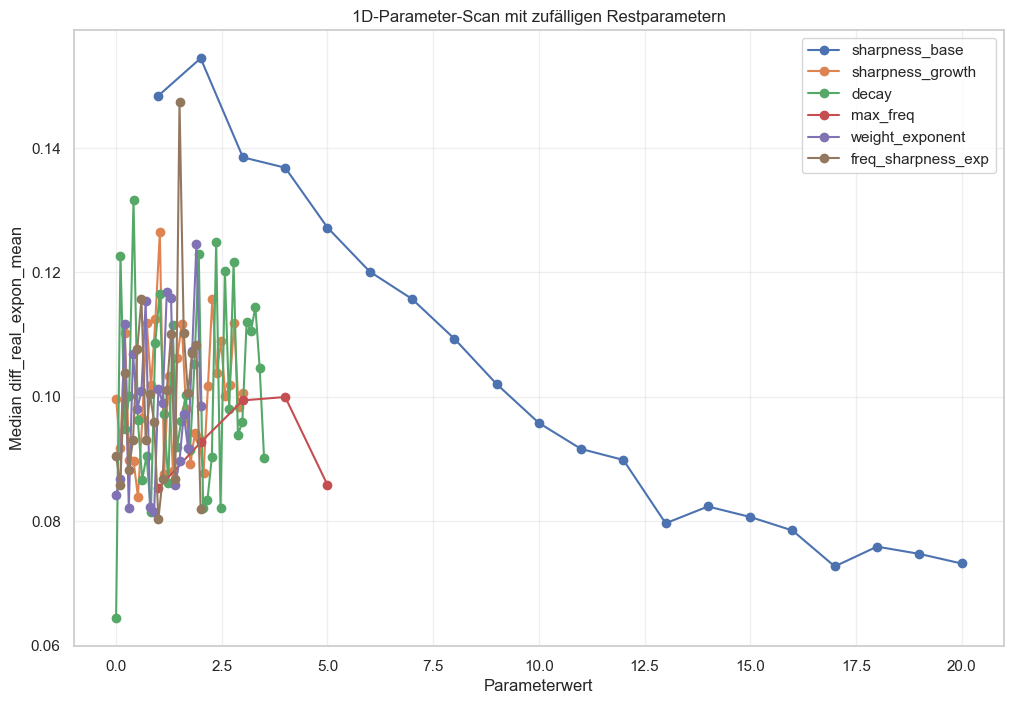

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion wie zuvor
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs


def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue
        fpath = os.path.join(folder_path, fname)
        df = pd.read_csv(fpath)
        if "IOI" not in df.columns:
            continue
        iois = df["IOI"].dropna().values
        sequence_length = len(iois)
        if sequence_length < 3:
            continue
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # Reale Proximity
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # Nullmodell Exponential
        proximity_expon_all = []
        for seq_idx in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        results_list.append({
            "filename": fname,
            "diff_real_expon_mean": mean_real - mean_expon
        })

    return pd.DataFrame(results_list)


# ================================
# 1D-Scan mit zufälligen anderen Parametern
# ================================
folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."
param_names = ["sharpness_base", "sharpness_growth", "decay", "max_freq", "weight_exponent", "freq_sharpness_exp"]
param_ranges = {
    "sharpness_base": np.linspace(1, 20, 20),
    "sharpness_growth": np.linspace(0, 3, 30),
    "decay": np.linspace(0, 3.5, 35),
    "max_freq": np.arange(1, 6),
    "weight_exponent": np.linspace(0, 2.0, 21),
    "freq_sharpness_exp": np.linspace(0, 2.0, 21)
}

num_random_samples = 20  # Anzahl der zufälligen Restparameter-Kombinationen
scan_results = []

rng = np.random.default_rng(42)

for pname in param_names:
    for val in param_ranges[pname]:
        medians = []
        for _ in range(num_random_samples):
            params = {p: rng.choice(param_ranges[p]) for p in param_names}  # zufällige andere Parameter
            params[pname] = val  # Scan-Parameter festlegen
            df_results = analyze_folder(folder_path, params, num_sequences=50)
            medians.append(df_results["diff_real_expon_mean"].median())
        scan_results.append({
            "parameter": pname,
            "value": val,
            "median_diff": np.mean(medians)
        })

scan_df = pd.DataFrame(scan_results)

# ================================
# Plot
# ================================
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
for pname in param_names:
    subset = scan_df[scan_df["parameter"] == pname]
    plt.plot(subset["value"], subset["median_diff"], marker="o", label=pname)
plt.xlabel("Parameterwert")
plt.ylabel("Median diff_real_expon_mean")
plt.title("1D-Parameter-Scan mit zufälligen Restparametern")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


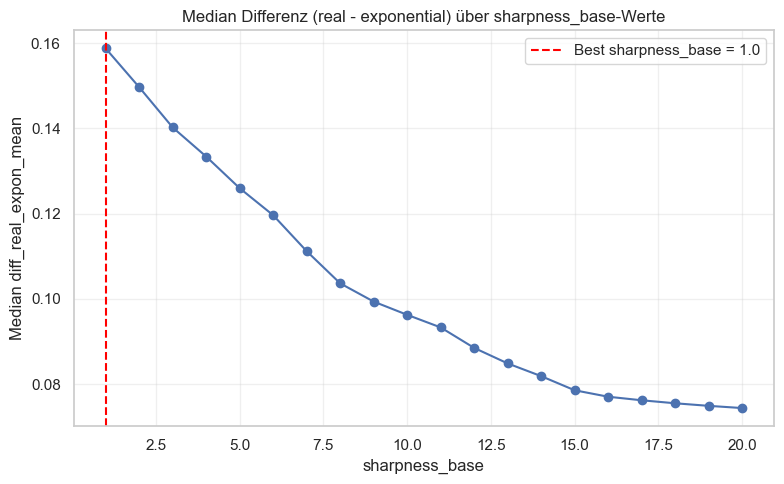

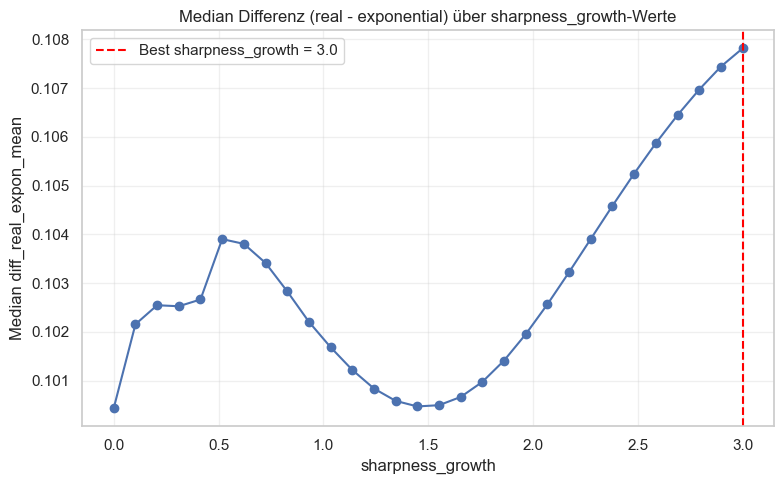

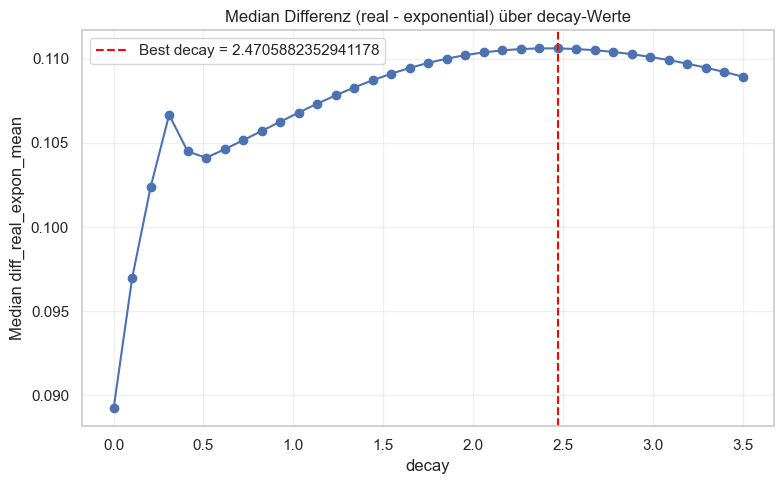

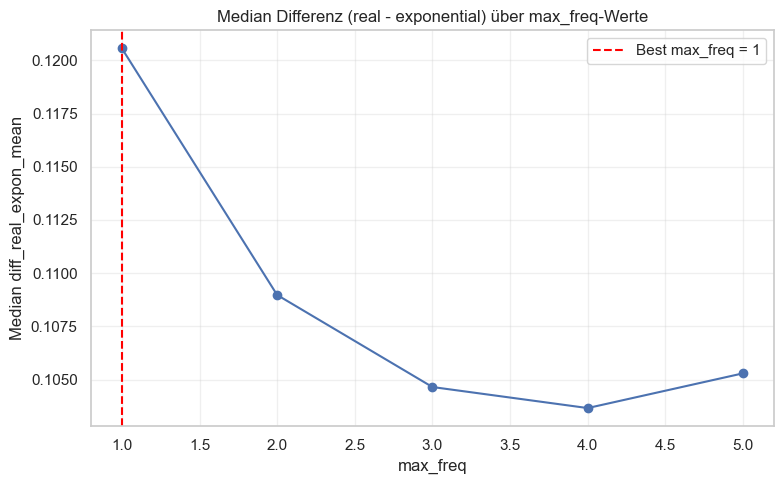

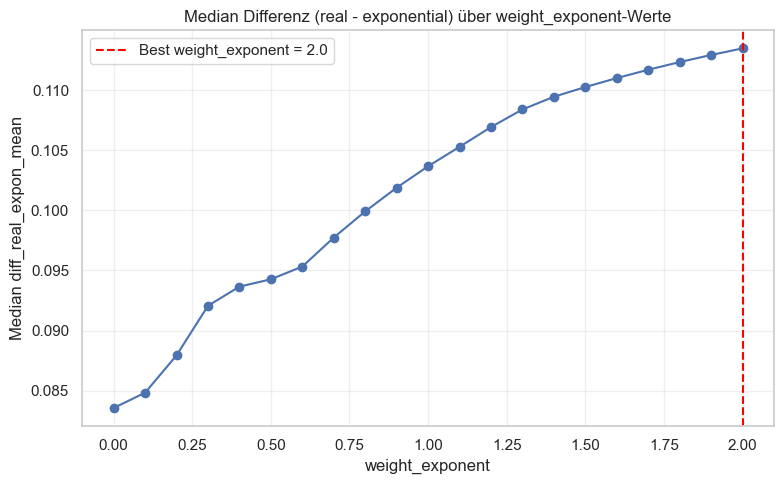

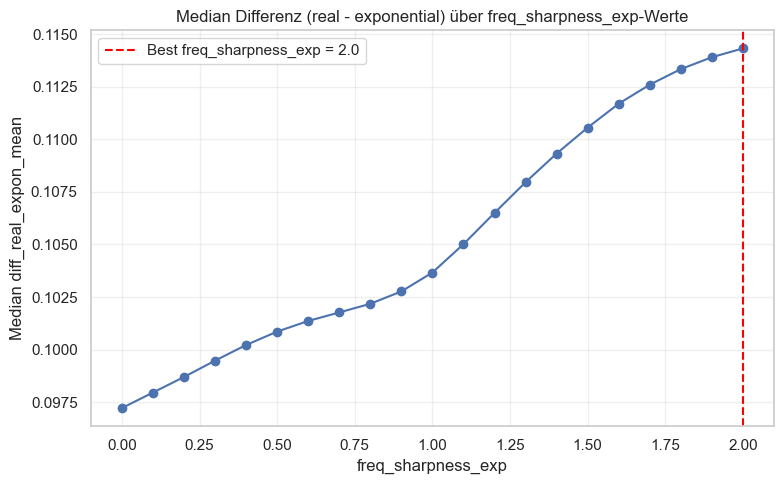

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs


# ================================
# Folder-Analyse
# ================================
def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Reale Proximity-Paare ---
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Nullmodell: Exponential ---
        proximity_expon_all = []
        for _ in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        # --- Nullmodell: Uniform ---
        proximity_uniform_all = []
        for _ in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_uniform_all.append(prox_mat[triu_idx])
        proximity_uniform_all = np.concatenate(proximity_uniform_all)
        mean_uniform = np.mean(proximity_uniform_all)

        results_list.append({
            "filename": fname,
            "real_mean": mean_real,
            "expon_mean": mean_expon,
            "uniform_mean": mean_uniform,
            "diff_real_expon_mean": mean_real - mean_expon,
            "diff_real_uniform_mean": mean_real - mean_uniform,
        })

    return pd.DataFrame(results_list)


# ================================
# Parameter-Scan
# ================================
param_ranges = {
    "sharpness_base": np.linspace(1, 20, 20),
    "sharpness_growth": np.linspace(0, 3, 30),
    "decay": np.linspace(0, 3.5, 70),
    "max_freq": np.arange(1, 10),
    "weight_exponent": np.linspace(0, 4.0, 41),
    "freq_sharpness_exp": np.linspace(0, 4.0, 41)
}

# Standardwerte für nicht-gescannte Parameter
default_params = {
    "sharpness_base": 8.0,
    "sharpness_growth": 0.5,
    "decay": 0.5,
    "max_freq": 4,
    "weight_exponent": 1.0,
    "freq_sharpness_exp": 1.0,
    "norm_x": 1.0,
    "output_max": 1.0
}

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."

# Alle Parameter nacheinander scannen
for param_name, values in param_ranges.items():
    all_results = []
    best_val = None
    best_median = -np.inf

    for val in values:
        params_test = default_params.copy()
        params_test[param_name] = val
        results_df = analyze_folder(folder_path, params_test, num_sequences=50, seed=42)
        median_val = results_df["diff_real_expon_mean"].median()
        all_results.append({"value": val, "median_diff": median_val})

        if median_val > best_median:
            best_median = median_val
            best_val = val

    summary_df = pd.DataFrame(all_results)

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(summary_df["value"], summary_df["median_diff"], marker="o", linestyle="-")
    plt.axvline(best_val, color="red", linestyle="--", label=f"Best {param_name} = {best_val}")
    plt.title(f"Median Differenz (real - exponential) über {param_name}-Werte")
    plt.xlabel(param_name)
    plt.ylabel("Median diff_real_expon_mean")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in multiply

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in multiply

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: RuntimeWarning:

overflow encountered in power

/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_5529/3610870263.py:29: Ru

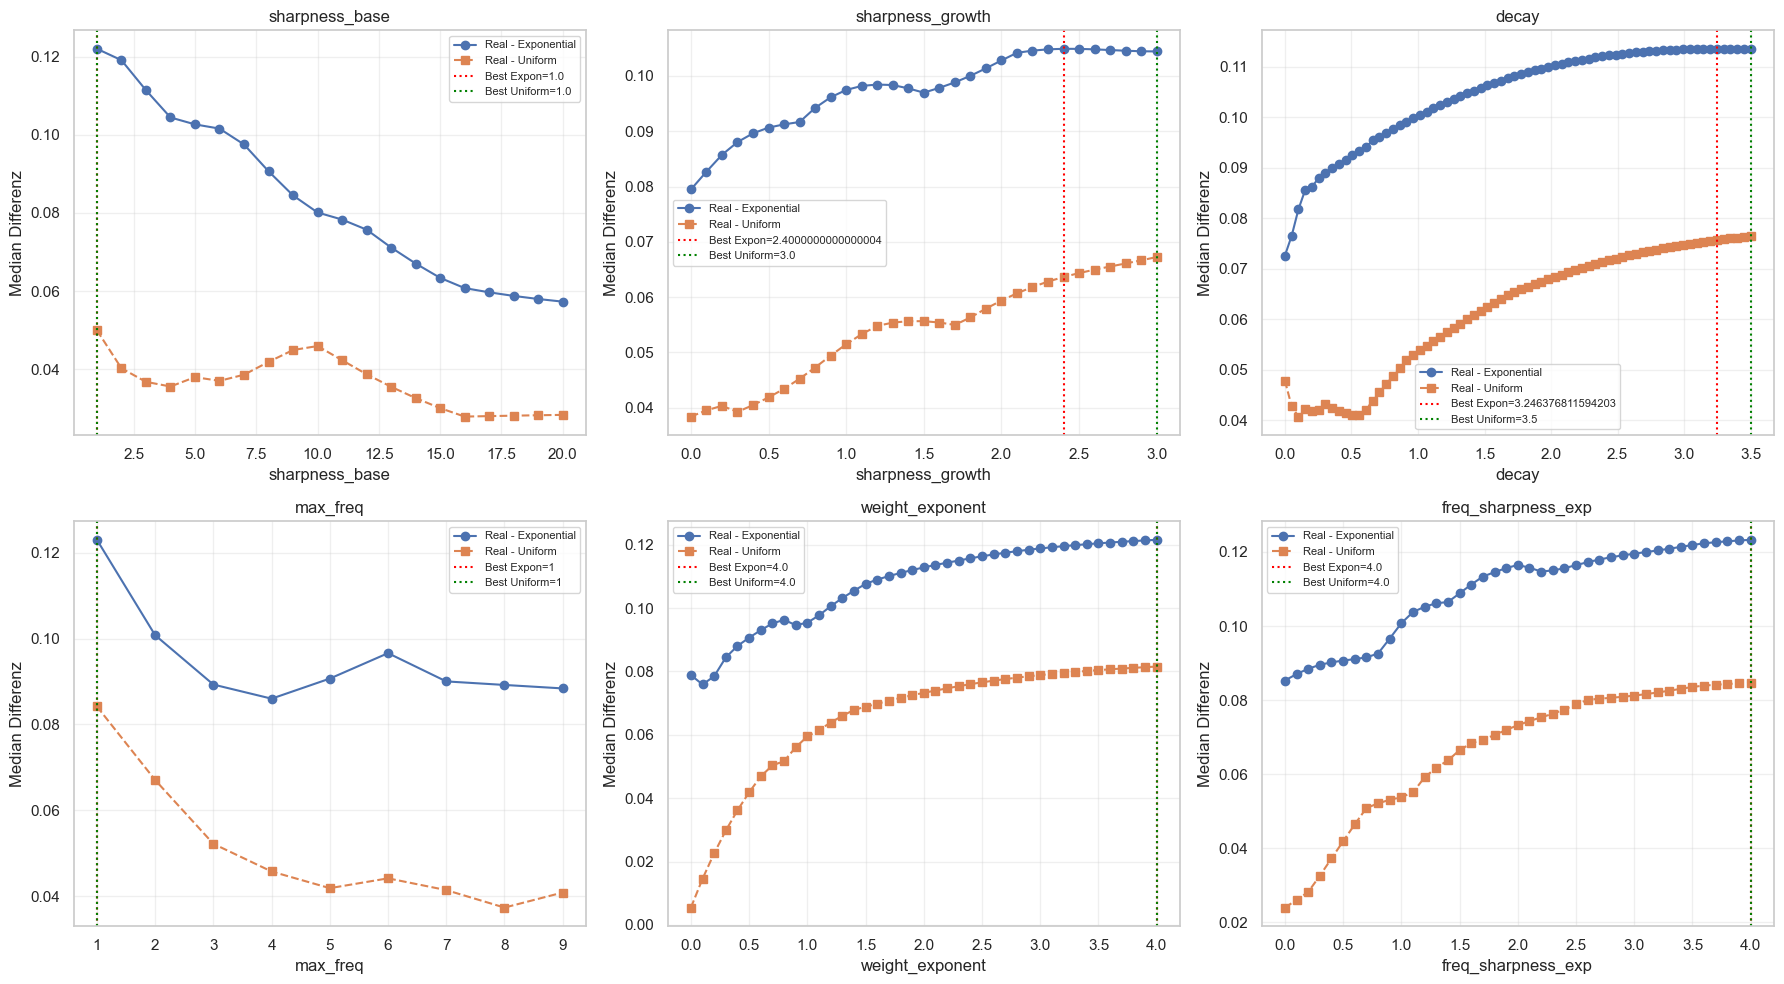

In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs


# ================================
# Folder-Analyse
# ================================
def analyze_folder(folder_path, params, num_sequences=10, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Reale Proximity-Paare ---
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real, _, _ = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Nullmodell: Exponential ---
        proximity_expon_all = []
        for _ in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        proximity_expon_all = np.concatenate(proximity_expon_all)
        mean_expon = np.mean(proximity_expon_all)

        # --- Nullmodell: Uniform ---
        proximity_uniform_all = []
        for _ in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat, _, _ = proximity_max_freq(ratios, **params)
            proximity_uniform_all.append(prox_mat[triu_idx])
        proximity_uniform_all = np.concatenate(proximity_uniform_all)
        mean_uniform = np.mean(proximity_uniform_all)

        results_list.append({
            "filename": fname,
            "real_mean": mean_real,
            "expon_mean": mean_expon,
            "uniform_mean": mean_uniform,
            "diff_real_expon_mean": mean_real - mean_expon,
            "diff_real_uniform_mean": mean_real - mean_uniform,
        })

    return pd.DataFrame(results_list)


# ================================
# Parameter-Scan mit Plots im Grid
# ================================
param_ranges = {
    "sharpness_base": np.linspace(1, 20, 20),
    "sharpness_growth": np.linspace(0, 3, 31),
    "decay": np.linspace(0, 3.5, 70),
    "max_freq": np.arange(1, 10),
    "weight_exponent": np.linspace(0, 4.0, 41),
    "freq_sharpness_exp": np.linspace(0, 4.0, 41)
}

default_params = {
    "sharpness_base": 8.0,
    "sharpness_growth": 0.5,
    "decay": 0.4,
    "max_freq": 5,
    "weight_exponent": 0.5,
    "freq_sharpness_exp": 0.5,
    "norm_x": 1.0,
    "output_max": 1.0
}

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (param_name, values) in enumerate(param_ranges.items()):
    all_results = []
    best_expon_val = None
    best_uniform_val = None
    best_expon_median = -np.inf
    best_uniform_median = -np.inf

    for val in values:
        params_test = default_params.copy()
        params_test[param_name] = val
        results_df = analyze_folder(folder_path, params_test, num_sequences=50, seed=42)

        median_expon = results_df["diff_real_expon_mean"].median()
        median_uniform = results_df["diff_real_uniform_mean"].median()

        all_results.append({"value": val,
                            "median_diff_expon": median_expon,
                            "median_diff_uniform": median_uniform})

        if median_expon > best_expon_median:
            best_expon_median = median_expon
            best_expon_val = val
        if median_uniform > best_uniform_median:
            best_uniform_median = median_uniform
            best_uniform_val = val

    summary_df = pd.DataFrame(all_results)
    ax = axes[i]

    ax.plot(summary_df["value"], summary_df["median_diff_expon"], marker="o", linestyle="-", label="Real - Exponential")
    ax.plot(summary_df["value"], summary_df["median_diff_uniform"], marker="s", linestyle="--", label="Real - Uniform")
    ax.axvline(best_expon_val, color="red", linestyle=":", label=f"Best Expon={best_expon_val}")
    ax.axvline(best_uniform_val, color="green", linestyle=":", label=f"Best Uniform={best_uniform_val}")
    ax.set_title(f"{param_name}")
    ax.set_xlabel(param_name)
    ax.set_ylabel("Median Differenz")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



=== Beste Parameter (Exponential) ===
norm_x                 1.000000
output_max             1.000000
sharpness_base         2.052513
sharpness_growth       0.523924
decay                  0.186837
max_freq               1.000000
weight_exponent        1.182288
freq_sharpness_exp     1.361429
median_diff_expon      0.181766
median_diff_uniform    0.128658
Name: 49, dtype: float64

=== Beste Parameter (Uniform) ===
norm_x                 1.000000
output_max             1.000000
sharpness_base         2.052513
sharpness_growth       0.523924
decay                  0.186837
max_freq               1.000000
weight_exponent        1.182288
freq_sharpness_exp     1.361429
median_diff_expon      0.181766
median_diff_uniform    0.128658
Name: 49, dtype: float64


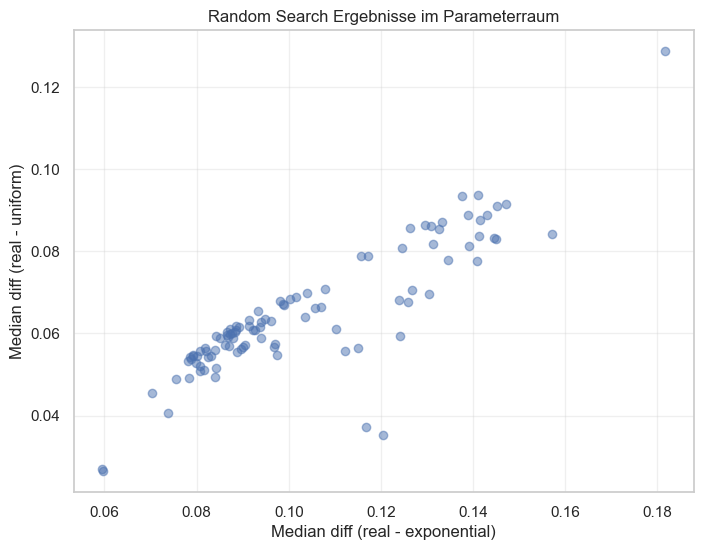

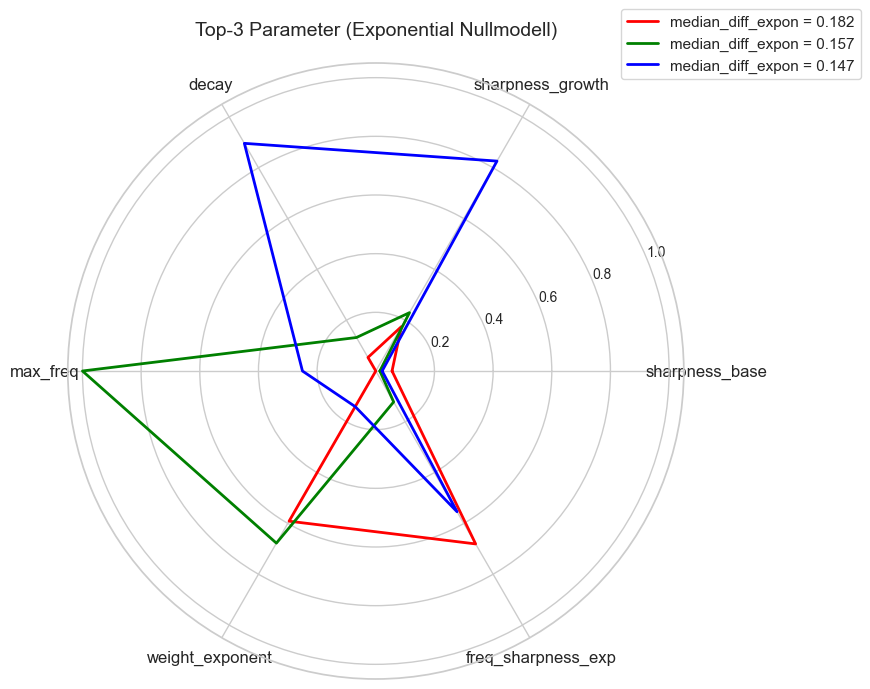

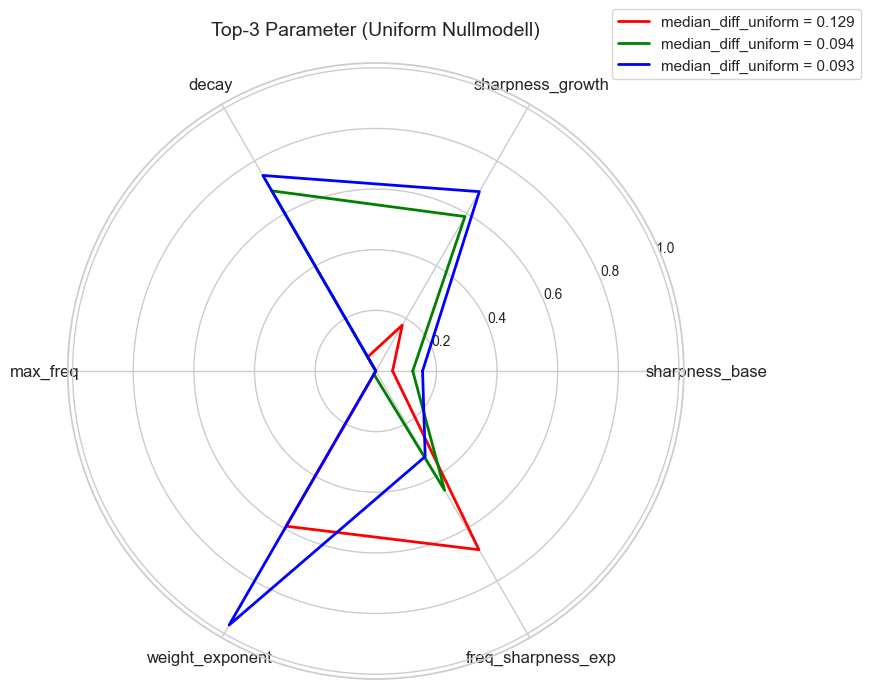

In [92]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Proximity-Funktion
# ================================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max


# ================================
# Folder-Analyse
# ================================
def analyze_folder(folder_path, params, num_sequences=500, seed=42):
    rng = np.random.default_rng(seed)
    results_list = []

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder_path, fname))
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        if len(iois) < 3:
            continue

        sequence_length = len(iois)
        max_ioi = float(np.max(iois))
        mean_ioi = float(np.mean(iois))

        # --- Real
        ratios_real = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j])
                                 for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat_real = proximity_max_freq(ratios_real, **params)
        triu_idx = np.triu_indices_from(prox_mat_real, k=1)
        proximity_real = prox_mat_real[triu_idx]
        mean_real = np.mean(proximity_real)

        # --- Exponential
        proximity_expon_all = []
        for _ in range(num_sequences):
            pois_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
            ratios = np.array([[max(pois_iois[i], pois_iois[j]) / min(pois_iois[i], pois_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat = proximity_max_freq(ratios, **params)
            proximity_expon_all.append(prox_mat[triu_idx])
        mean_expon = np.mean(np.concatenate(proximity_expon_all))

        # --- Uniform
        proximity_uniform_all = []
        for _ in range(num_sequences):
            unif_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
            ratios = np.array([[max(unif_iois[i], unif_iois[j]) / min(unif_iois[i], unif_iois[j])
                                for j in range(sequence_length)] for i in range(sequence_length)])
            prox_mat = proximity_max_freq(ratios, **params)
            proximity_uniform_all.append(prox_mat[triu_idx])
        mean_uniform = np.mean(np.concatenate(proximity_uniform_all))

        results_list.append({
            "filename": fname,
            "real_mean": mean_real,
            "expon_mean": mean_expon,
            "uniform_mean": mean_uniform,
            "diff_real_expon_mean": mean_real - mean_expon,
            "diff_real_uniform_mean": mean_real - mean_uniform,
        })

    return pd.DataFrame(results_list)

# ================================
# Random Search über Parameterraum
# ================================
def random_search(
    folder_path,
    n_samples=100,
    num_sequences=500,
    seed=42
):
    """
    Führt Random Search über den Parameterraum aus und gibt Ergebnisse zurück.

    Parameters
    ----------
    folder_path : str
        Pfad zum Ordner mit den CSV-Dateien.
    n_samples : int
        Anzahl zufälliger Parameterkombinationen, die getestet werden.
    num_sequences : int
        Anzahl zufälliger Nullmodell-Sequenzen pro Datei.
    seed : int
        Zufalls-Seed.

    Returns
    -------
    summary_df : pd.DataFrame
        DataFrame mit allen getesteten Parameterkombinationen und Median-Differenzen.
    best_expon : pd.Series
        Parameterkombination mit maximalem Median-Differenz (real - exponential).
    best_uniform : pd.Series
        Parameterkombination mit maximalem Median-Differenz (real - uniform).
    """
    rng = np.random.default_rng(seed)

    # Parameterbereiche definieren
    param_ranges = {
    "sharpness_base": (1, 50),
    "sharpness_growth": (0, 5),
    "decay": (0, 4),
    "max_freq": (1, 6),
    "weight_exponent": (0, 4.0),
    "freq_sharpness_exp": (0, 4.0)
    }
    default_params = {"norm_x": 1.0, "output_max": 1.0}

    all_results = []

    for i in range(n_samples):
        # Zufällige Parameterkombination erzeugen
        params = {} if default_params is None else default_params.copy()
        params["sharpness_base"] = rng.uniform(*param_ranges["sharpness_base"])
        params["sharpness_growth"] = rng.uniform(*param_ranges["sharpness_growth"])
        params["decay"] = rng.uniform(*param_ranges["decay"])
        params["max_freq"] = rng.integers(param_ranges["max_freq"][0], param_ranges["max_freq"][1] + 1)
        params["weight_exponent"] = rng.uniform(*param_ranges["weight_exponent"])
        params["freq_sharpness_exp"] = rng.uniform(*param_ranges["freq_sharpness_exp"])

        # Analyse
        results_df = analyze_folder(folder_path, params, num_sequences=num_sequences, seed=seed)
        if results_df.empty:
            continue

        median_expon = results_df["diff_real_expon_mean"].median()
        median_uniform = results_df["diff_real_uniform_mean"].median()

        all_results.append({
            **params,
            "median_diff_expon": median_expon,
            "median_diff_uniform": median_uniform
        })

    # Alles in DataFrame packen
    summary_df = pd.DataFrame(all_results)

    if not summary_df.empty:
        best_expon = summary_df.loc[summary_df["median_diff_expon"].idxmax()]
        best_uniform = summary_df.loc[summary_df["median_diff_uniform"].idxmax()]
    else:
        best_expon, best_uniform = None, None

    return summary_df, best_expon, best_uniform

# ================================
# Aufruf der Random Search
# ================================

folder_path = "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp."

summary_df, best_expon, best_uniform = random_search(
    folder_path,
    n_samples=100,
    num_sequences=500,
    seed=42
)

print("\n=== Beste Parameter (Exponential) ===")
print(best_expon)
print("\n=== Beste Parameter (Uniform) ===")
print(best_uniform)

# ================================
# Visualisierung
# ================================
plt.figure(figsize=(8,6))
plt.scatter(summary_df["median_diff_expon"], summary_df["median_diff_uniform"], alpha=0.5)
plt.xlabel("Median diff (real - exponential)")
plt.ylabel("Median diff (real - uniform)")
plt.title("Random Search Ergebnisse im Parameterraum")
plt.grid(True, alpha=0.3)
plt.show()

# ================================
# Radarplot für Top-3 Parameterkombinationen (nur Linien, mit Grid)
# ================================
def plot_radar_top3(summary_df, mode="expon", param_ranges=param_ranges):
    """
    Radarplot der Top-3 Parameterkombinationen (Linien, mit globaler Normalisierung).
    mode = "expon" oder "uniform"
    """
    if mode == "expon":
        top = summary_df.nlargest(3, "median_diff_expon")
        value_col = "median_diff_expon"
        title = "Top-3 Parameter (Exponential Nullmodell)"
    else:
        top = summary_df.nlargest(3, "median_diff_uniform")
        value_col = "median_diff_uniform"
        title = "Top-3 Parameter (Uniform Nullmodell)"

    # Parameter
    params = ["sharpness_base", "sharpness_growth", "decay",
              "max_freq", "weight_exponent", "freq_sharpness_exp"]

    # --- Globale Normalisierung auf param_ranges ---
    normed = top[params].copy()
    for p in params:
        low, high = param_ranges[p]
        normed[p] = (normed[p] - low) / (high - low)

    # Winkel
    num_vars = len(params)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    # Plot
    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    colors = ["red", "green", "blue"]

    for i, (idx, row) in enumerate(normed.iterrows()):
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=2,
                label=f"{value_col} = {top.iloc[i][value_col]:.3f}")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(params, fontsize=12)

    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)

    ax.set_title(title, size=14, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Aufruf
plot_radar_top3(summary_df, mode="expon")
plot_radar_top3(summary_df, mode="uniform")
